# C06 · Galaxies: how many clusters, and who belongs where?

| | |
|---|---|
| **Difficulty** | ★★★☆☆ |
| **Time** | 3-4 hours |
| **Data** | Postman, Huchra & Geller (1986) via Roeder (1990): recession velocities of 82 galaxies in the Corona Borealis region |
| **Skills** | Finite mixture models · diagnosing a sampler whose chains disagree · constrained parameters and initial values · marginalised vs explicit discrete assignments · membership and co-clustering probabilities · choosing K with LOO and PPCs (and knowing when you cannot) · predictive probabilities of a void |

## The brief

An astronomy group has measured the recession velocities of 82 galaxies in six well-separated
conic sections of sky towards Corona Borealis. By Hubble's law velocity is a proxy for
distance, so if galaxies were spread evenly through space the velocities would form one
smooth hump. Theories of large-scale structure say otherwise: galaxies should sit in
**clusters separated by voids**, which would show up as several humps with gaps in between.

The group asks three questions:

1. Do the velocities show distinct clusters separated by voids, and **how many**?
2. **Which galaxies belong together?** For the ones near a boundary, how sure are you?
3. Is the apparent **void** between the main body and the fastest galaxies real, or the kind
   of gap that 82 draws from a smooth distribution produce by chance?

They want answers with uncertainty, in language they can put in a paper.

## How this notebook works

- Each task states **what to deliver**, not how. Write your code in the `YOUR CODE HERE` cells.
- Stuck? `h.hint("task2")` reveals hints one level at a time: *nudge → approach → code skeleton*.
  Try to get by on nudges.
- `h.check("task2", mu_main=...)` compares your numbers with the reference solution.
- A full worked solution lives in `notebooks/solutions/`. Open it only when you are done (or truly stuck).

In [1]:
import time

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy import stats

from pymc_challenges import Hints, data

RANDOM_SEED = 1986
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

h = Hints("C06")
h.tasks()

**C06 - Galaxies: how many clusters, and who belongs where?**

- `task0` - Look at the data (2 hints)
- `task1` - The textbook mixture (3 hints, 1 check(s))
- `task2` - Fix the model (3 hints, 3 check(s))
- `task3` - Membership probabilities, two ways (3 hints, 2 check(s))
- `task4` - How many clusters? (3 hints, 2 check(s))
- `task5` - Unequal spreads and heavy tails (3 hints, 2 check(s))
- `task6` - Co-clustering and the void (3 hints, 3 check(s))

## The data

A single column, `dat`: velocity in km/s. We sort it and work in **thousands of km/s**, so
galaxy 0 is the nearest and galaxy 81 the most distant, and sensible prior scales are of
order 1-10 rather than 1,000-10,000.

A historical footnote: this is the version distributed with R's `MASS` package, which
contains a famous typo - the 78th value is 26690 where Roeder's paper has 26960. It makes no
difference to anything below, but it is the reason published analyses of "the galaxy data"
do not always agree to the last digit.

In [2]:
data.describe("galaxies")
galaxies = data.load("galaxies")
v = np.sort(galaxies["dat"].to_numpy() / 1000)
N = len(v)
print(N, "galaxies, from", v.min(), "to", v.max(), "thousand km/s")

galaxies: Velocities (km/s) of 82 galaxies in the Corona Borealis region.
  source: Postman, Huchra & Geller (1986) via Roeder (1990) and R package `MASS`.
  url:    https://vincentarelbundock.github.io/Rdatasets/csv/MASS/galaxies.csv
82 galaxies, from 9.172 to 34.279 thousand km/s


## Task 0 · Look at the data

**Deliver** a plot that shows every single galaxy (82 points deserve better than a 10-bin
histogram alone) and a list of the largest gaps between neighbouring velocities. How many
groups do you see, how many galaxies in each, and how wide is each group?

,from,to,gap
6,10.406,16.084,5.678
78,26.995,32.065,5.070
8,16.170,18.419,2.249
80,32.789,34.279,1.490
76,25.633,26.690,1.057


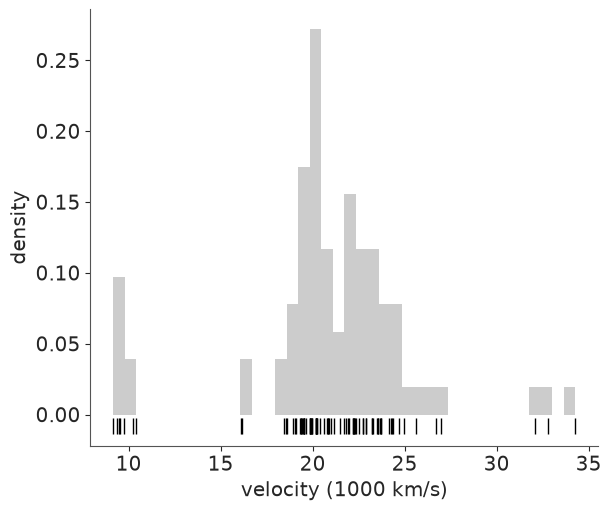

In [3]:
def plot_velocities(ax=None, bins=40):
    ax = ax or plt.gca()
    ax.hist(v, bins=bins, density=True, color="0.8")
    ax.plot(v, np.full(N, -0.008), "|", color="k", ms=12)
    ax.set(xlabel="velocity (1000 km/s)", ylabel="density")
    return ax


plot_velocities()

gaps = pd.DataFrame({"from": v[:-1], "to": v[1:], "gap": np.diff(v)}).sort_values("gap", ascending=False)
gaps.head(5).round(3)

In [4]:
groups = pd.cut(v, [0, 13, 29, 40], labels=["near", "main", "far"])
pd.DataFrame({"v": v, "group": groups}).groupby("group", observed=True).v.agg(["size", "mean", "std", "min", "max"]).round(2)

,size,mean,std,min,max
group,,,,,
near,7,9.71,0.46,9.17,10.41
main,72,21.40,2.21,16.08,27.00
far,3,33.04,1.13,32.06,34.28


Three groups, separated by the two largest gaps (5.7 and 5.1 thousand km/s - the next
largest is 2.2): a tight **near** group of 7 galaxies around 9,700 km/s, a **main** body of
72 between 16,000 and 27,000, and a **far** group of just 3 beyond 32,000. Two things to
remember for later. The groups are very unequal in width: the near group has a standard
deviation of 0.46, the main body 2.2. And the main body is not obviously one hump: the
histogram dips around 21, and a pair of galaxies at 16.1 sits 2,200 km/s below the rest.

## Task 1 · The textbook mixture

Fit a mixture of **three Gaussians**: three means, one standard deviation shared by all
components, and three mixture weights. Write it the way a textbook would, with **the same
prior for every component** - nothing in the model should distinguish "component 0" from
"component 2". Use the default four chains.

**Deliver**
1. The summary table and whatever plots you need to decide whether you can trust it.
2. A diagnosis. Be precise: what exactly went wrong, is any *individual* chain wrong, and
   is there a quantity in the summary table that is perfectly fine - and why that one?

### Solution

Priors: means anywhere in the surveyed range (`Normal(20, 10)`), a spread of a few thousand
km/s at most (`HalfNormal(3)`), and a flat Dirichlet on the weights. `pm.NormalMixture`
sums over the unknown component of each galaxy inside the likelihood.

In [5]:
K = 3
with pm.Model(coords={"component": range(K)}) as naive_model:
    mu = pm.Normal("mu", 20, 10, dims="component")
    sigma = pm.HalfNormal("sigma", 3)
    w = pm.Dirichlet("w", np.ones(K), dims="component")
    pm.NormalMixture("velocity", w=w, mu=mu, sigma=sigma, observed=v)
    naive_idata = pm.sample(random_seed=RANDOM_SEED)

print("divergences:", int(naive_idata.sample_stats["diverging"].sum()))
az.summary(naive_idata, round_to=2)

NUTS[nutpie]: [mu, sigma, w]


divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu[0],18.42,9.47,8.92,33.61,5.26,11.07,2.30,4.70,1.85
mu[1],21.21,11.41,8.89,34.25,6.11,36.73,1.73,5.66,0.02
mu[2],24.18,4.89,21.03,33.59,7.17,10.69,1.53,2.41,1.42
sigma,2.14,0.17,1.89,2.42,4363.78,2957.72,1.00,0.00,0.00
w[0],0.27,0.34,0.03,0.89,5.56,10.65,1.94,0.17,0.10
w[1],0.07,0.04,0.02,0.14,10.11,43.24,1.31,0.01,0.00
w[2],0.65,0.35,0.03,0.91,7.16,10.77,1.53,0.17,0.10


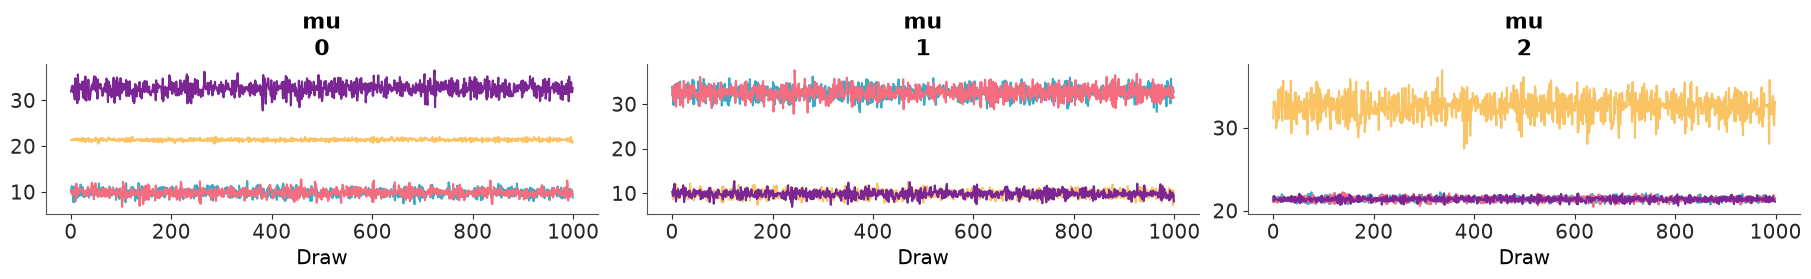

In [6]:
az.plot_trace(naive_idata, var_names=["mu"]);

In [7]:
naive_idata.posterior["mu"].mean("draw").to_pandas().round(1)

component,0,1,2
chain,,,
0,9.9,32.6,21.4
1,9.8,32.5,21.4
2,21.4,9.9,32.6
3,32.6,9.9,21.4


In [8]:
max_rhat = float(az.rhat(naive_idata.posterior["mu"]).max())
assert h.check("task1", max_rhat=max_rhat)

- PASS `max_rhat` = 2.303 is consistent with the reference solution.

The summary is a disaster - `r_hat` between 1.5 and 2.3 for the means and the weights,
effective sample sizes in single digits - and yet there are **no divergences**, and the trace
of every chain is a flat, well-mixed band. The per-chain table explains it. Every chain found
the same three clusters, at 9.9, 21.4 and 32.6, but they disagree about what to *call* them:
chains 0 and 1 use the order (near, far, main), chain 2 (main, near, far), chain 3 (far, near,
main).

Nothing in the prior or the likelihood distinguishes the components, so the posterior
consists of 3! = 6 identical copies of the same mode, one for each way of naming the
clusters. The copies are separated by regions of very low probability, so a chain stays in
whichever copy it falls into first. **Each chain is a perfectly good sample of one copy.**
`r_hat` compares the variation *between* chains with the variation *within* them, sees
chains sitting at 9.9 and 32.6 for "the same" parameter, and rightly reports that they have
not converged to a common distribution. The pooled estimate `mu[0] = 18.4 ± 9.5` is an
average over names and means nothing.

The exception is `sigma`: `r_hat` 1.00 and over 4,000 effective draws. It is shared by all
components, so it does not care what they are called. The same holds for any quantity
that is invariant to relabelling - the fitted density, for instance. This is called
**label switching**, and it is a property of the model, not a failure of the sampler: no
`target_accept` or longer run will cure it. (A sampler good enough to jump between the
copies would make every marginal an identical three-humped mixture - also useless.)

## Task 2 · Fix the model

**Deliver**
1. A three-component mixture with the same likelihood and clean diagnostics. Fix the
   *model*, not the sampler settings. If your fix refuses to start sampling, find out which
   term of the log-probability is to blame before changing anything else.
2. Evidence for your Task 1 diagnosis: get an acceptable `r_hat` for the means out of the
   *Task 1* posterior draws, without refitting anything.
3. One sentence each: does your fix change the fitted density? Would it still work if two
   clusters had nearly the same mean?

### Solution

The standard fix is an **ordering constraint** $\mu_0 < \mu_1 < \mu_2$: of the 3! = 6
equivalent labellings exactly one satisfies it, so the posterior keeps one of the six
mirror-image modes. `transform=pm.distributions.transforms.ordered` does this by sampling
the first mean and the log of the gaps between neighbours.

The catch is the starting point. All three means start at the prior mean, the gaps are zero,
and the log of zero is `-inf`:

In [9]:
ordered = pm.distributions.transforms.ordered

with pm.Model(coords={"component": range(K)}) as ordered_model:
    mu = pm.Normal("mu", 20, 10, dims="component", transform=ordered)
    sigma = pm.HalfNormal("sigma", 3)
    w = pm.Dirichlet("w", np.ones(K), dims="component")
    pm.NormalMixture("velocity", w=w, mu=mu, sigma=sigma, observed=v)

print("default start, on the transformed scale:", ordered_model.initial_point()["mu_ordered__"])
print("log-probability terms there:", ordered_model.point_logps())

default start, on the transformed scale: [ 20. -inf -inf]
log-probability terms there: {'mu': np.float64(-inf), 'sigma': np.float64(-0.73), 'w': np.float64(-1.5), 'velocity': np.float64(-262.29)}


So the transform needs **strictly increasing initial values**. Spreading them evenly over
the range of the data is a good general-purpose choice: it also starts each component near
a different part of the data, which matters more and more as the mixtures get flexible
(Task 5). We pass them to `pm.sample` rather than as `initval=` on the variable, because
`pm.compute_log_likelihood` - needed for LOO in Task 4 - refuses models with non-default
initial values.

In [10]:
def spread_init(K):
    return {"mu": np.linspace(v.min(), v.max(), K)}


with ordered_model:
    start = time.time()
    ordered_idata = pm.sample(initvals=spread_init(K), random_seed=RANDOM_SEED)
    ordered_seconds = time.time() - start

print("divergences:", int(ordered_idata.sample_stats["diverging"].sum()))
az.summary(ordered_idata, round_to=3)

NUTS[nutpie]: [mu, sigma, w]


divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu[0],9.831,0.835,8.461,11.129,989.246,1066.294,1.001,0.027,0.018
mu[1],21.391,0.256,20.975,21.782,4580.242,3069.682,0.999,0.004,0.004
mu[2],32.626,1.362,30.365,34.718,3910.650,2784.405,1.002,0.022,0.022
sigma,2.135,0.170,1.883,2.422,4069.507,3160.009,1.004,0.003,0.003
w[0],0.095,0.032,0.049,0.151,3871.288,2354.077,1.001,0.000,0.001
w[1],0.856,0.038,0.791,0.911,4112.381,2792.220,1.000,0.001,0.001
w[2],0.049,0.024,0.017,0.092,4335.119,2623.276,1.000,0.000,0.000


In [11]:
# Part 2: relabel the naive draws after the fact, by sorting the means within every draw
naive_mu = naive_idata.posterior["mu"]
relabelled = naive_mu.copy(data=np.sort(naive_mu.values, axis=-1))
print("r_hat of mu, naive draws as sampled: ", az.rhat(naive_mu).values.round(2))
print("r_hat of mu, naive draws relabelled:", az.rhat(relabelled).values.round(3))
print("posterior means, relabelled naive:  ", relabelled.mean(("chain", "draw")).values.round(2))
print("posterior means, ordered model:     ", ordered_idata.posterior["mu"].mean(("chain", "draw")).values.round(2))

r_hat of mu, naive draws as sampled:  [2.3  1.73 1.53]
r_hat of mu, naive draws relabelled: [1.001 1.001 1.001]
posterior means, relabelled naive:   [ 9.86 21.39 32.56]
posterior means, ordered model:      [ 9.83 21.39 32.63]


In [12]:
post = ordered_idata.posterior
assert h.check(
    "task2",
    mu_main=post["mu"].sel(component=1).mean(),
    w_main=post["w"].sel(component=1).mean(),
    sigma=post["sigma"].mean(),
)

- PASS `mu_main` = 21.39 is consistent with the reference solution.
- PASS `w_main` = 0.8562 is consistent with the reference solution.
- PASS `sigma` = 2.135 is consistent with the reference solution.

Clean: no divergences, `r_hat` of 1.00 throughout, roughly 1,000 effective draws or more. The
clusters sit at 9.8, 21.4 and 32.6 with weights 0.10, 0.86 and 0.05 and a common spread of
2.1.

**The naive chains were fine.** Sorting the means within each draw maps all six copies onto
one, and the `r_hat` of the naive fit drops from 2.3 to 1.001, with the same posterior means
as the ordered model. (Relabelling after the fact like this works here because the clusters
are far apart; doing it properly means permuting `w` along with `mu`.)

**Does the constraint change the fit?** No. Prior and likelihood are symmetric, so
restricting to $\mu_0 < \mu_1 < \mu_2$ keeps exactly one of six identical copies; the
implied density over velocities is untouched.

**Would it always work?** No. Ordering the means only separates the labels if the means are
far apart relative to their posterior uncertainty. Two clusters with nearly equal means
(but, say, different spreads) can still swap roles *inside* the ordered region. Then you
order on a different parameter, or drop exchangeability and give each component its own
informative prior (`mu ~ Normal([10, 21, 33], 2)`) - a softer fix that requires you to know
roughly where the clusters are. Keep this in mind for Tasks 4 and 5.

## Task 3 · Which galaxies belong together?

The mixture likelihood you have been using sums over the unknown cluster of each galaxy,
so the cluster assignments appear nowhere in the posterior. The astronomers want them.

**Deliver**
1. From the Task 2 posterior, $P(\text{galaxy } i \text{ belongs to cluster } k)$ for every
   galaxy and cluster. Plot it against velocity. Which galaxies are genuinely ambiguous?
2. The same model written the other way: with an explicit discrete assignment for every
   galaxy. Compare what the sampler had to do, how long it took, the effective sample sizes
   and the membership probabilities.
3. Which formulation would you use by default, and why?

### Solution

Given parameters $\theta = (w, \mu, \sigma)$, Bayes' rule for a single galaxy gives the
**responsibility** of cluster $k$:

$$r_{ik}(\theta) = P(z_i = k \mid v_i, \theta) =
\frac{w_k \, \text{N}(v_i \mid \mu_k, \sigma_k)}{\sum_j w_j \, \text{N}(v_i \mid \mu_j, \sigma_j)}$$

Averaging $r_{ik}$ over posterior draws of $\theta$ integrates the parameters out and
gives the membership probability. Nothing needs to be refitted. (The helper takes an
optional `nu` so that it also works for the Student-t components of Task 5.)

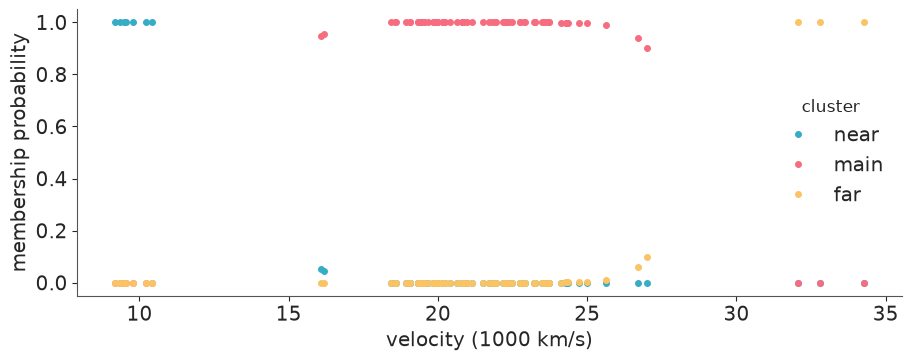

In [13]:
def responsibilities(idata, x=v, nu=None, num_samples=None):
    """P(z = k | x, theta) for every posterior draw: array (draws, len(x), K)."""
    post = az.extract(idata, var_names=["mu", "sigma", "w"], num_samples=num_samples, random_seed=RANDOM_SEED)
    mu, w = post["mu"].values.T[:, None, :], post["w"].values.T[:, None, :]  # (draws, 1, K)
    sigma = post["sigma"].values
    sigma = sigma.T[:, None, :] if sigma.ndim == 2 else sigma[:, None, None]
    z = (np.asarray(x)[None, :, None] - mu) / sigma
    logpdf = stats.norm.logpdf(z) if nu is None else stats.t.logpdf(z, nu)
    log_r = np.log(w) + logpdf - np.log(sigma)
    log_r -= log_r.max(axis=-1, keepdims=True)
    r = np.exp(log_r)
    return r / r.sum(axis=-1, keepdims=True)


CLUSTERS = ["near", "main", "far"]
resp = responsibilities(ordered_idata)
membership = pd.DataFrame(resp.mean(axis=0), columns=CLUSTERS, index=pd.Index(v, name="velocity"))

fig, ax = plt.subplots(figsize=(9, 3.5))
for k, name in enumerate(CLUSTERS):
    ax.plot(v, membership[name], "o", ms=4, color=f"C{k}", label=name)
ax.set(xlabel="velocity (1000 km/s)", ylabel="membership probability")
ax.legend(title="cluster");

In [14]:
ambiguous = membership[membership.max(axis=1) < 0.99]
ambiguous.round(3)

,near,main,far
velocity,,,
16.084,0.052,0.948,0.000
16.170,0.043,0.957,0.000
26.690,0.000,0.939,0.061
26.995,0.000,0.900,0.100


Now the explicit version. Each galaxy gets a `Categorical` assignment `z`, and the
likelihood is an ordinary Normal around `mu[z]`. NUTS cannot move discrete variables, so
PyMC builds a compound sampler: NUTS for the continuous parameters, a Gibbs-type
Metropolis step for the 82 assignments.

In [15]:
with pm.Model(coords={"component": range(K), "galaxy": range(N)}) as explicit_model:
    mu = pm.Normal("mu", 20, 10, dims="component", transform=ordered)
    sigma = pm.HalfNormal("sigma", 3)
    w = pm.Dirichlet("w", np.ones(K), dims="component")
    z = pm.Categorical("z", p=w, dims="galaxy")
    pm.Normal("velocity", mu[z], sigma, observed=v, dims="galaxy")
    start = time.time()
    explicit_idata = pm.sample(initvals=spread_init(K), random_seed=RANDOM_SEED)
    explicit_seconds = time.time() - start

az.summary(explicit_idata, var_names=["mu", "sigma", "w"], round_to=3)

Multiprocess sampling (4 chains in 4 jobs)


CompoundStep


>NUTS: [mu, sigma, w]


>CategoricalGibbsMetropolis: [z]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:90: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu[0],9.852,0.846,8.520,11.231,2066.676,1978.957,1.002,0.019,0.015
mu[1],21.399,0.262,20.974,21.813,3025.236,3136.174,1.000,0.005,0.004
mu[2],32.598,1.338,30.408,34.683,2144.544,1427.792,1.001,0.029,0.024
sigma,2.136,0.172,1.877,2.420,3587.063,2495.131,1.004,0.003,0.003
w[0],0.095,0.031,0.050,0.149,3581.494,2403.663,1.001,0.001,0.001
w[1],0.856,0.038,0.792,0.912,3726.236,3033.438,1.000,0.001,0.001
w[2],0.049,0.023,0.018,0.091,3397.035,2484.387,1.002,0.000,0.000


In [16]:
z_draws = explicit_idata.posterior["z"].stack(sample=("chain", "draw")).values  # (galaxy, draws)
membership_explicit = pd.DataFrame(
    {name: (z_draws == k).mean(axis=1) for k, name in enumerate(CLUSTERS)}, index=membership.index
)
print(f"wall-clock time including compilation: marginalised {ordered_seconds:.0f} s, explicit {explicit_seconds:.0f} s")
print(f"largest difference in any membership probability: {np.abs(membership_explicit - membership).values.max():.3f}")

ess = pd.DataFrame({
    name: az.summary(idata, var_names=["mu", "sigma", "w"])["ess_bulk"].astype(float)
    for name, idata in [("marginalised", ordered_idata), ("explicit", explicit_idata)]
})
ess.round(0)

wall-clock time including compilation: marginalised 1 s, explicit 4 s
largest difference in any membership probability: 0.013


,marginalised,explicit
mu[0],989.0,2067.0
mu[1],4580.0,3025.0
mu[2],3911.0,2145.0
sigma,4070.0,3587.0
w[0],3871.0,3581.0
w[1],4112.0,3726.0
w[2],4335.0,3397.0


In [17]:
assert h.check(
    "task3",
    p_main_16084=membership.loc[16.084, "main"],
    p_main_26995=membership.loc[26.995, "main"],
)

- PASS `p_main_16084` = 0.9483 is consistent with the reference solution.
- PASS `p_main_26995` = 0.8997 is consistent with the reference solution.

Only four galaxies are at all ambiguous, and they are the ones next to the two voids: the
pair at 16.1 (main body with probability 0.95, otherwise near group) and the two just below
27 (0.94 and 0.90 main body, otherwise far group). Everything else is assigned with
probability above 0.99.

The two formulations are the same model and give the same answers: identical parameter
summaries, and membership probabilities within 0.013 of each other - Monte Carlo noise
in the explicit version, which estimates each probability by counting how often a discrete
`z` took a value, whereas the marginalised version averages exact conditional probabilities.
(The `RuntimeWarning` comes from computing `r_hat` for assignments that never change.)

With clusters this well separated the explicit sampler copes: its effective sample sizes
are in the same range (lower for five of the seven parameters, higher for the near-cluster
mean). But it needed a compound sampler with 82 extra discrete variables, cannot use
nutpie, and took several times longer. It also scales badly: when components overlap, a
Gibbs step that moves one galaxy at a time is slow to reassign a whole group, and there is
no gradient to help. **Marginalise by default** - you lose nothing, because the assignments
can always be recovered afterwards as above. Reach for explicit assignments only when
something downstream needs them inside the model.

## Task 4 · How many clusters?

Three was the eye's answer. Let the data have a say: fit the same shared-spread mixture for
**K = 2, 3, 4, 5, 6**.

**Deliver**
1. A table of sampler diagnostics per K (worst `r_hat`, smallest bulk ESS, divergences).
   Do not expect all of them to be pretty - say what the ugly ones are telling you.
2. The `az.compare` table, and how far you trust it with N = 82.
3. A posterior predictive check that separates at least one K from the rest: the fitted
   density over the data, plus a test statistic aimed at something the astronomers care
   about.
4. For the largest K: what do the posterior weights of the extra components look like?
5. Your answer to "how many clusters?", with the honest amount of hedging.

In [18]:
def fit_mixture(K, kind="shared", nu=4, target_accept=0.95):
    """Ordered K-component mixture. kind: 'shared' sd, 'unequal' sds, or 'student' (unequal sds, t components)."""
    with pm.Model(coords={"component": range(K), "galaxy": range(N)}) as model:
        mu = pm.Normal("mu", 20, 10, dims="component", transform=ordered)
        w = pm.Dirichlet("w", np.ones(K), dims="component")
        if kind == "shared":
            sigma = pm.HalfNormal("sigma", 3)
            pm.NormalMixture("velocity", w=w, mu=mu, sigma=sigma, observed=v, dims="galaxy")
        else:
            sigma = pm.LogNormal("sigma", 0, 0.5, dims="component")
            if kind == "unequal":
                pm.NormalMixture("velocity", w=w, mu=mu, sigma=sigma, observed=v, dims="galaxy")
            else:
                components = pm.StudentT.dist(nu=nu, mu=mu, sigma=sigma, shape=K)
                pm.Mixture("velocity", w=w, comp_dists=components, observed=v, dims="galaxy")
        idata = pm.sample(initvals=spread_init(K), target_accept=target_accept, random_seed=RANDOM_SEED)
        pm.compute_log_likelihood(idata, progressbar=False)
    return model, idata


def diagnostics(fits):
    rows = {}
    for name, (_, idata) in fits.items():
        summ = az.summary(idata, var_names=["mu", "sigma", "w"])
        rows[name] = {"max r_hat": summ.r_hat.astype(float).max(), "min bulk ESS": summ.ess_bulk.astype(float).min(),
                      "divergences": int(idata.sample_stats["diverging"].sum())}
    return pd.DataFrame(rows).T


shared = {f"K={k}": fit_mixture(k) for k in range(2, 7)}
diagnostics(shared).round(3)

NUTS[nutpie]: [mu, w, sigma]


NUTS[nutpie]: [mu, w, sigma]


NUTS[nutpie]: [mu, w, sigma]


NUTS[nutpie]: [mu, w, sigma]


NUTS[nutpie]: [mu, w, sigma]


,max r_hat,min bulk ESS,divergences
K=2,1.006,723.270,0.0
K=3,1.005,1011.385,0.0
K=4,1.005,458.664,0.0
K=5,1.021,282.505,1.0
K=6,1.024,181.417,0.0


In [19]:
comparison = az.compare({name: idata for name, (_, idata) in shared.items()})
comparison

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
K=6,0,0.0,0.0,NaN,,2 k̂ > 0.70,12.5,-210.0,9.3,0.91
K=4,1,-4.0,2.3,0.97,N < 100,,7.3,-220.0,9.5,0.00
K=5,2,-4.0,2.3,0.98,N < 100,,9.1,-220.0,9.8,0.00
K=3,3,-5.0,3.1,0.96,N < 100,,4.7,-220.0,9.4,0.00
K=2,4,-20.0,9.1,0.99,N < 100,,5.9,-240.0,14.0,0.09


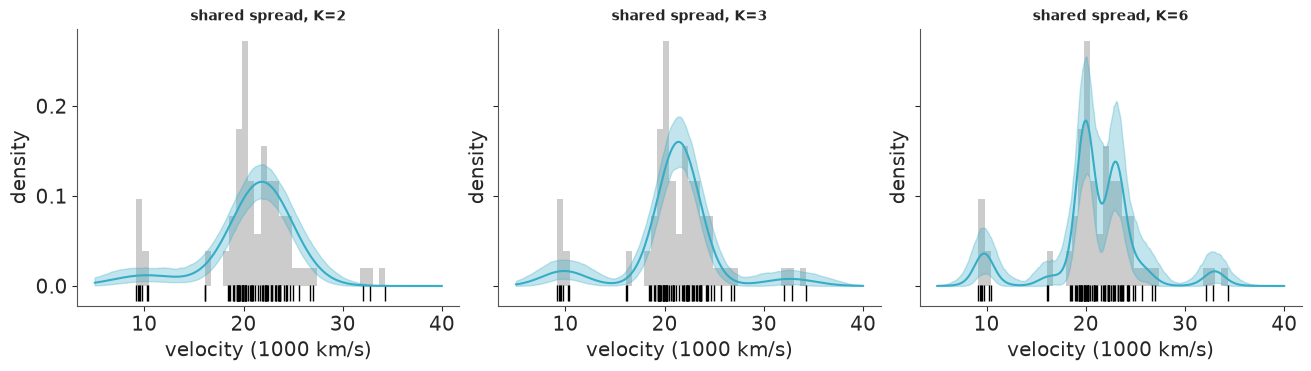

In [20]:
x_grid = np.linspace(5, 40, 400)


def density_draws(idata, nu=None, num_samples=500):
    """Posterior draws of the mixture density on x_grid: (draws, len(x_grid))."""
    post = az.extract(idata, var_names=["mu", "sigma", "w"], num_samples=num_samples, random_seed=RANDOM_SEED)
    mu, w = post["mu"].values.T[:, None, :], post["w"].values.T[:, None, :]
    sigma = post["sigma"].values
    sigma = sigma.T[:, None, :] if sigma.ndim == 2 else sigma[:, None, None]
    z = (x_grid[None, :, None] - mu) / sigma
    pdf = stats.norm.pdf(z) if nu is None else stats.t.pdf(z, nu)
    return (w * pdf / sigma).sum(axis=-1)


def plot_density(idata, ax, title, nu=None, color="C0"):
    dens = density_draws(idata, nu=nu)
    lo, hi = np.quantile(dens, [0.03, 0.97], axis=0)
    plot_velocities(ax)
    ax.fill_between(x_grid, lo, hi, color=color, alpha=0.3)
    ax.plot(x_grid, dens.mean(axis=0), color=color)
    ax.set_title(title, fontsize=10)


fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, name in zip(axes, ["K=2", "K=3", "K=6"]):
    plot_density(shared[name][1], ax, f"shared spread, {name}")

In [21]:
# Test statistic: how many of 82 galaxies in a replicated survey are faster than 30,000 km/s? (observed: 3)
rows = {}
for name, (model, idata) in shared.items():
    with model:
        ppc = pm.sample_posterior_predictive(idata, random_seed=RANDOM_SEED, progressbar=False)
    n_far = (ppc.posterior_predictive["velocity"] > 30).sum("galaxy").values.ravel()
    rows[name] = {"mean": n_far.mean(), "P(none)": (n_far == 0).mean(), "P(3 or more)": (n_far >= 3).mean()}
print("observed number of galaxies above 30:", int((v > 30).sum()))
pd.DataFrame(rows).T.round(3)

Sampling: [velocity]


Sampling: [velocity]


Sampling: [velocity]


Sampling: [velocity]


Sampling: [velocity]


observed number of galaxies above 30: 3


,mean,P(none),P(3 or more)
K=2,0.395,0.700,0.017
K=3,3.334,0.091,0.568
K=4,3.502,0.074,0.599
K=5,3.602,0.074,0.608
K=6,3.662,0.075,0.615


In [22]:
k6 = shared["K=6"][1]
w6 = az.extract(k6, var_names="w").values  # (component, draws)
pd.DataFrame({
    "mean of mu": k6.posterior["mu"].mean(("chain", "draw")).values,
    "mean of w": w6.mean(axis=1),
    "expected galaxies": N * w6.mean(axis=1),
    "P(w < 1/82)": (w6 < 1 / N).mean(axis=1),
}, index=pd.Index(range(6), name="component")).round(3)

,mean of mu,mean of w,expected galaxies,P(w < 1/82)
component,,,,
0,9.643,0.090,7.387,0.012
1,16.374,0.063,5.126,0.077
2,20.040,0.406,33.274,0.007
3,22.827,0.306,25.112,0.006
4,25.600,0.090,7.373,0.030
5,33.005,0.045,3.729,0.030


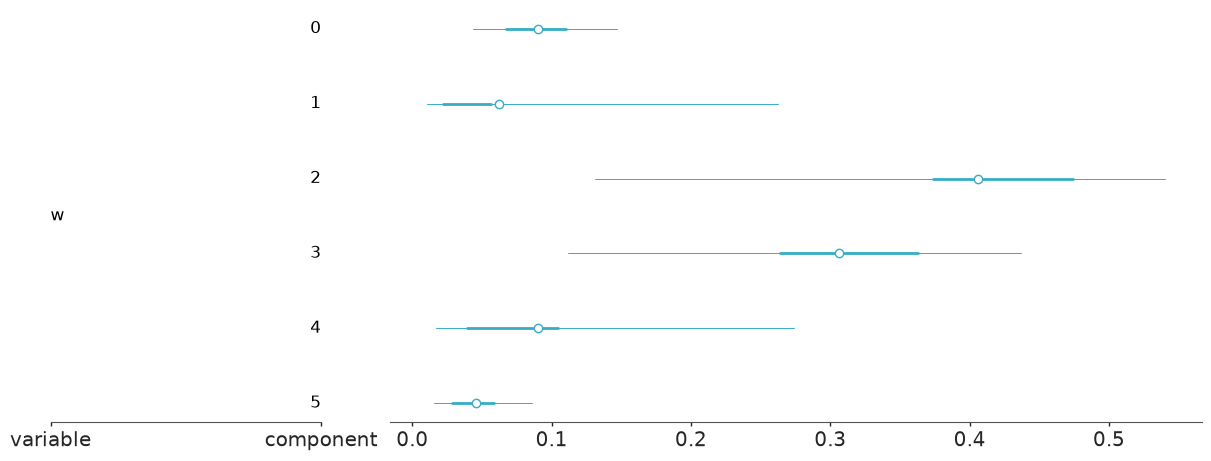

In [23]:
az.plot_forest(k6, var_names=["w"], combined=True);

In [24]:
elpd = {name: az.loo(idata).elpd for name, (_, idata) in shared.items()}
assert h.check(
    "task4",
    elpd_gain_3_vs_2=elpd["K=3"] - elpd["K=2"],
    sigma_k6=k6.posterior["sigma"].mean(),
)

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


- PASS `elpd_gain_3_vs_2` = 17.57 is consistent with the reference solution.
- PASS `sigma_k6` = 1.007 is consistent with the reference solution.

**Diagnostics.** K = 2 to 4 sample cleanly. K = 5 and 6 are usable but visibly harder
(`r_hat` 1.02, a couple of hundred effective draws, a stray divergence), even at
`target_accept=0.95`. The ordering constraint removed the relabelling copies, but an
over-specified mixture has other ways to be multimodal: a component the data do not need can
sit on the pair at 16.1, help tile the main body, or wait in the upper tail, and the sampler
has to move between these. Sticky sampling at large K is itself a symptom of redundancy.

**LOO** is clear about one thing: K = 2 is not enough (about 18 elpd behind K = 3, 20 behind
the leader). Among the rest it barely discriminates. K = 3, 4 and 5 are within 1-2 elpd of
each other; K = 6 leads them by 4-5 with a standard error of 2-3 - under two standard
errors, with N = 82 flagged as small and two Pareto-k values above 0.7 for K = 6, which
make precisely that estimate the least trustworthy one in the table.

**Posterior predictive checks** agree. K = 2 has to treat the three far galaxies as the
tail of the main body: a replicated survey contains 0.4 galaxies above 30,000 km/s on
average and three or more only 2% of the time. Every K of 3 or more reproduces the far
group (3.3-3.7 on average) - the check cannot tell them apart. In the density plot K = 6
differs from K = 3 mainly by splitting the main body into two humps at about 20 and 23.

**Weights.** At K = 6 the two big components carry 0.41 and 0.31; the two extra ones (at
16.4 and 25.6) get 0.06 and 0.09, with intervals stretching from about 0.01 to 0.27. They
are not empty - each found a handful of galaxies to explain - but how many is almost
undetermined. Note also what happened to `sigma`: it halved, from 2.1 at K = 3 to 1.0.
Hold that thought for Task 5.

**Answer so far:** at least three clusters, and the two voids appear in every model with
K >= 3. Whether the main body is one cluster or several, 82 velocities and this model
family cannot say.

## Task 5 · Clusters are not all the same size

One standard deviation for a group of 7 tightly packed galaxies *and* for a main body that
spans 10,000 km/s is an assumption of convenience. Relax it, in two steps, staying with
K = 3:

- each cluster gets **its own standard deviation**;
- additionally, the components get **heavy tails** (Student-t with a small, fixed number of
  degrees of freedom), the usual recipe for making a mixture robust to stragglers.

**Deliver**
1. A prior for the cluster spreads that an astronomer would sign off on. (Rich galaxy
   clusters have velocity dispersions of the order of 1,000 km/s.)
2. Both fits with their diagnostics. More flexible mixtures have more ways to go wrong:
   watch the initial values, and if a fit misbehaves work out *what* it is undecided about.
3. A LOO comparison with all the Task 4 models. What was K = 6 really doing?
4. What changed for the boundary galaxies of Task 3?

### Solution

`LogNormal(0, 0.5)` puts the median spread at 1,000 km/s with 95% of its mass between about
400 and 2,700 km/s: centred on what a rich cluster looks like, with room for a looser
structure. It also keeps a component from inflating into a flat "background" that covers
everything, which is the classic way for an unequal-variance mixture to go wrong.
`fit_mixture` above already knows the two new kinds.

In [25]:
flexible = {"K=3 unequal": fit_mixture(3, kind="unequal"), "K=3 student-t": fit_mixture(3, kind="student")}
diagnostics(flexible).round(3)

NUTS[nutpie]: [mu, w, sigma]


NUTS[nutpie]: [mu, w, sigma]


,max r_hat,min bulk ESS,divergences
K=3 unequal,1.005,1680.611,0.0
K=3 student-t,1.085,34.388,0.0


In [26]:
az.summary(flexible["K=3 unequal"][1], var_names=["mu", "sigma", "w"], round_to=3)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu[0],9.721,0.243,9.340,10.108,1680.611,1795.579,1.005,0.006,0.006
mu[1],21.395,0.260,20.980,21.800,3888.696,2992.643,1.002,0.004,0.004
mu[2],32.902,0.895,31.584,34.071,1982.491,1371.683,1.003,0.025,0.048
sigma[0],0.635,0.205,0.384,1.004,2600.208,2263.378,1.000,0.004,0.005
sigma[1],2.180,0.181,1.908,2.487,3883.814,2905.867,1.000,0.003,0.003
sigma[2],1.258,0.555,0.683,2.220,2084.429,1634.886,1.002,0.015,0.024
w[0],0.093,0.031,0.049,0.147,3922.513,2797.585,1.000,0.000,0.001
w[1],0.859,0.037,0.795,0.914,3756.547,2983.965,1.001,0.001,0.001
w[2],0.048,0.024,0.017,0.092,3467.144,2487.475,1.001,0.000,0.000


In [27]:
az.summary(flexible["K=3 student-t"][1], var_names=["mu", "sigma", "w"], round_to=3)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu[0],9.693,0.264,9.284,10.113,1744.099,1760.508,1.003,0.006,0.006
mu[1],19.995,0.519,19.511,21.298,34.388,12.797,1.081,0.133,0.147
mu[2],23.633,3.113,21.805,32.662,49.104,12.580,1.083,0.866,1.148
sigma[0],0.616,0.221,0.349,1.023,3208.112,2153.685,1.001,0.005,0.007
sigma[1],0.843,0.443,0.431,1.895,40.140,13.954,1.070,0.104,0.106
sigma[2],1.922,0.439,1.111,2.547,85.847,30.239,1.045,0.061,0.071
w[0],0.093,0.031,0.048,0.148,3372.431,2820.941,1.002,0.001,0.001
w[1],0.385,0.192,0.177,0.862,42.823,12.130,1.085,0.046,0.051
w[2],0.522,0.194,0.044,0.737,42.573,11.920,1.080,0.046,0.051


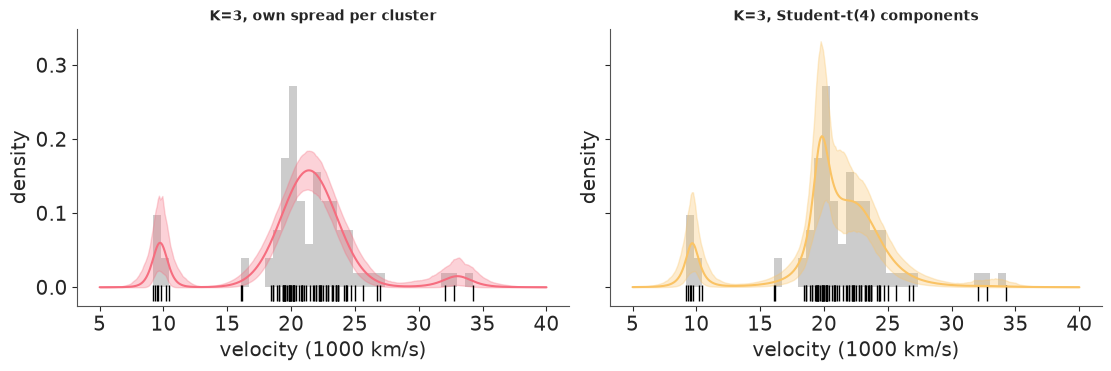

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
plot_density(flexible["K=3 unequal"][1], axes[0], "K=3, own spread per cluster", color="C1")
plot_density(flexible["K=3 student-t"][1], axes[1], "K=3, Student-t(4) components", nu=4, color="C2")

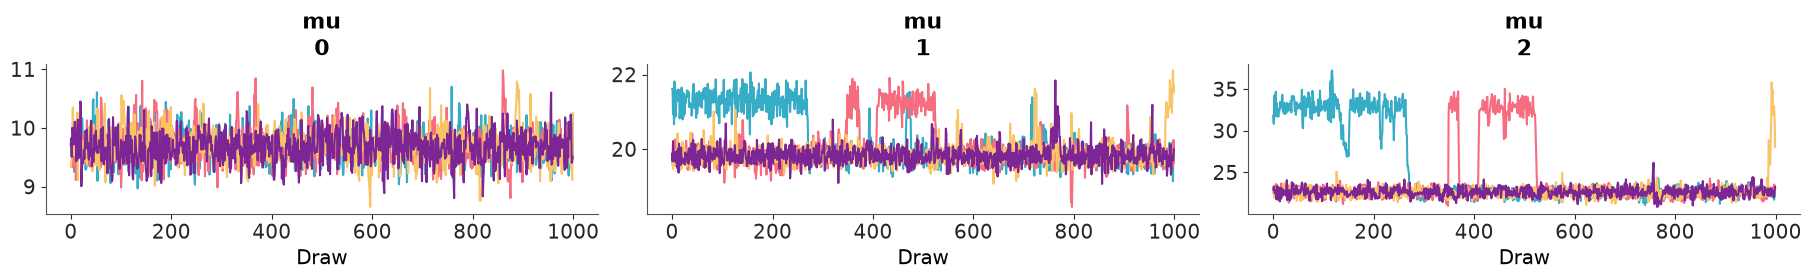

In [29]:
az.plot_trace(flexible["K=3 student-t"][1], var_names=["mu"]);

In [30]:
all_fits = {**shared, **flexible}
comparison_all = az.compare({name: idata for name, (_, idata) in all_fits.items()})
comparison_all

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
K=3 unequal,0,0.0,0.0,NaN,,1 k̂ > 0.70,6.3,-210.0,8.5,0.55
K=6,1,-2.0,2.8,0.71,N < 100,2 k̂ > 0.70,12.5,-210.0,9.3,0.02
K=3 student-t,2,-2.0,4.6,0.70,N < 100,,9.7,-210.0,11.0,0.43
K=4,3,-6.0,2.5,0.99,N < 100,,7.3,-220.0,9.5,0.00
K=5,4,-6.0,2.7,0.99,N < 100,,9.1,-220.0,9.8,0.00
K=3,5,-7.0,2.5,1.00,N < 100,,4.7,-220.0,9.4,0.00
K=2,6,-20.0,8.6,1.00,N < 100,,5.9,-240.0,14.0,0.00


In [31]:
final_idata = flexible["K=3 unequal"][1]
resp_final = responsibilities(final_idata)
membership_final = pd.DataFrame(resp_final.mean(axis=0), columns=CLUSTERS, index=membership.index)
boundary = [10.406, 16.084, 16.170, 18.419, 25.633, 26.690, 26.995, 32.065]
pd.concat({"shared spread": membership.loc[boundary], "own spread": membership_final.loc[boundary]}, axis=1).round(3)

shared spread               own spread              
                  near   main    far       near   main    far
velocity                                                     
10.406           1.000  0.000  0.000        1.0  0.000  0.000
16.084           0.052  0.948  0.000        0.0  1.000  0.000
16.170           0.043  0.957  0.000        0.0  1.000  0.000
18.419           0.000  1.000  0.000        0.0  1.000  0.000
25.633           0.000  0.990  0.010        0.0  0.994  0.006
26.690           0.000  0.939  0.061        0.0  0.982  0.018
26.995           0.000  0.900  0.100        0.0  0.975  0.025
32.065           0.000  0.001  0.999        0.0  0.001  0.999

In [32]:
post = final_idata.posterior
assert h.check(
    "task5",
    sigma_near=post["sigma"].sel(component=0).mean(),
    sigma_main=post["sigma"].sel(component=1).mean(),
)

- PASS `sigma_near` = 0.6352 is consistent with the reference solution.
- PASS `sigma_main` = 2.18 is consistent with the reference solution.

**Own spread per cluster.** Clean diagnostics, and the spreads are as different as Task 0
suggested: 0.64 for the near group, 2.2 for the main body and 1.3 for the far group (wide
interval, 0.7-2.2: three galaxies and a prior).

**What was K = 6 really doing?** The unequal-spread K = 3 model ties with shared-spread K = 6
at the top of the table (difference 2, standard error 2.8) using half the effective
parameters (6 against 12.5), and beats shared-spread K = 3, 4 and 5 by 6-7 elpd with a
standard error of 2.5. A single spread cannot be right for both a group with sd 0.5 and one
with sd 2.2. Given one spread only, the best the model can do is to shrink it (from 2.1 at
K = 3 to 1.0 at K = 6) and tile the main body with several narrow components. Much of the
apparent evidence for "many clusters" was evidence against "equal spreads". One Pareto-k
warning remains, so treat differences of a few elpd as ties.

**Heavy tails.** The Student-t fit has `r_hat` 1.08 and a few dozen effective draws, and the
trace shows why. This is *not* label switching - the means are ordered. The chains jump
between two different **explanations** of the data: one where the third component is the far
group (means near 21 and 33), and one where components two and three split the main body
at about 20 and 23 and the three far galaxies are absorbed by the tails as stragglers.
Heavy tails make three galaxies 10,000 km/s away cheap to explain without a cluster of
their own, which frees the third component to do something else. With so few jumps the time
spent in each explanation is not estimated reliably, so every number from this fit (including
its row in the LOO table, a tie with the leaders) is rough. The lesson is about modelling:
robustness changes what "cluster" means. For a question that is *about* small distant groups
and the voids around them, a component that explains them away is the wrong tool, and we
do not use it below.

**Boundary galaxies.** With a tight near cluster the pair at 16.1 belongs to the main body
with certainty (before: 0.95), and the two galaxies just below 27 are now main-body members
with probability 0.98 rather than 0.90-0.94, because the far group is no longer credited
with the main body's width.

## Task 6 · What the astronomers can say

Two deliverables for the paper. Use the model you would defend, and show how much the
answers move under a credible alternative.

**1. Co-clustering.** Cluster labels are a modelling convenience; "are galaxies *i* and *j*
in the same cluster?" is not. **Deliver** the posterior co-clustering probability for all
pairs (a picture) and for the pairs listed below (numbers).

**2. The void.** No galaxy was observed between 27,500 and 31,500 km/s. **Deliver** the
posterior predictive mass of that interval, the number of galaxies a new survey of the same
size should expect to find in it, and the probability that such a survey finds it empty
again. Compare with what a single smooth (one-component) population would predict. Then
write the two or three sentences that go in the paper.

In [33]:
VOID = (27.5, 31.5)
PAIRS = [(16.084, 16.170), (16.084, 10.406), (16.084, 18.419), (26.995, 25.633), (26.995, 32.065)]

### Solution

Given the parameters the assignments of two different galaxies are independent, so
$P(z_i = z_j \mid \theta) = \sum_k r_{ik}\, r_{jk}$; averaging over posterior draws gives the
co-clustering probability. It is invariant to relabelling - you could compute it from the
*naive* Task 1 fit and get the right answer - and it can be compared across models with
different K.

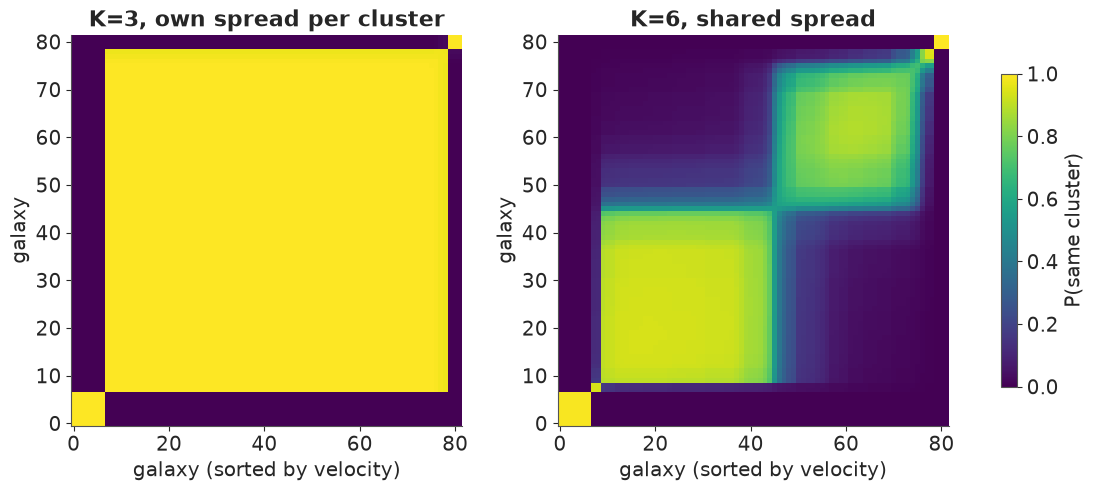

In [34]:
def coclustering(resp):
    """Posterior P(z_i = z_j) from responsibilities (draws, N, K): array (N, N)."""
    return np.einsum("sik,sjk->ij", resp, resp) / resp.shape[0]


cc_final = coclustering(resp_final)
cc_k6 = coclustering(responsibilities(shared["K=6"][1], num_samples=1000))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, cc, title in zip(axes, [cc_final, cc_k6], ["K=3, own spread per cluster", "K=6, shared spread"]):
    im = ax.imshow(cc, cmap="viridis", vmin=0, vmax=1, origin="lower")
    ax.set(title=title, xlabel="galaxy (sorted by velocity)", ylabel="galaxy")
    ax.grid(False)
fig.colorbar(im, ax=axes, label="P(same cluster)", shrink=0.8);

In [35]:
idx = {val: int(np.argmin(np.abs(v - val))) for pair in PAIRS for val in pair}
pair_table = pd.DataFrame(
    {"K=3 own spread": [cc_final[idx[a], idx[b]] for a, b in PAIRS],
     "K=6 shared spread": [cc_k6[idx[a], idx[b]] for a, b in PAIRS]},
    index=[f"{a} & {b}" for a, b in PAIRS],
)
pair_table.round(3)

,K=3 own spread,K=6 shared spread
16.084 & 16.17,1.000,0.940
16.084 & 10.406,0.000,0.001
16.084 & 18.419,1.000,0.168
26.995 & 25.633,0.977,0.821
26.995 & 32.065,0.026,0.001


In [36]:
def interval_mass(idata, lo, hi, nu=None):
    """Posterior draws of the predictive mass of [lo, hi] under a fitted mixture."""
    post = az.extract(idata, var_names=["mu", "sigma", "w"])
    mu, w, sigma = post["mu"].values.T, post["w"].values.T, post["sigma"].values
    sigma = sigma.T if sigma.ndim == 2 else sigma[:, None]
    cdf = (lambda x: stats.norm.cdf((x - mu) / sigma)) if nu is None else (lambda x: stats.t.cdf((x - mu) / sigma, nu))
    return (w * (cdf(hi) - cdf(lo))).sum(axis=1)


rows = {}
for name, nu in [("K=3 unequal", None), ("K=3", None), ("K=6", None), ("K=3 student-t", 4)]:
    mass = interval_mass(all_fits[name][1], *VOID, nu=nu)
    rows[name] = {"mass": mass.mean(), "expected galaxies": N * mass.mean(),
                  "lo": N * np.quantile(mass, 0.03), "hi": N * np.quantile(mass, 0.97),
                  "P(empty)": ((1 - mass) ** N).mean()}

# a single smooth population, fitted by moments
single = stats.norm(v.mean(), v.std(ddof=1))
m1 = single.cdf(VOID[1]) - single.cdf(VOID[0])
rows["single Normal"] = {"mass": m1, "expected galaxies": N * m1, "P(empty)": (1 - m1) ** N}
void_table = pd.DataFrame(rows).T
void_table.round(3)

,mass,expected galaxies,lo,hi,P(empty)
K=3 unequal,0.010,0.792,0.102,2.869,0.542
K=3,0.018,1.460,0.235,4.144,0.335
K=6,0.008,0.667,0.037,2.442,0.602
K=3 student-t,0.018,1.481,0.557,2.989,0.269
single Normal,0.062,5.100,NaN,NaN,0.005


In [37]:
assert h.check(
    "task6",
    coclust_16084_18419=pair_table.loc["16.084 & 18.419", "K=3 own spread"],
    void_expected=void_table.loc["K=3 unequal", "expected galaxies"],
    p_void_empty=void_table.loc["K=3 unequal", "P(empty)"],
)

- PASS `coclust_16084_18419` = 0.9998 is consistent with the reference solution.
- PASS `void_expected` = 0.7919 is consistent with the reference solution.
- PASS `p_void_empty` = 0.5422 is consistent with the reference solution.

**Who belongs together.** The three-way split by the two voids is solid under both models:
galaxies on opposite sides of a void share a cluster with probability 0.03 or less (16.084
with 10.406: 0.00; 26.995 with 32.065: 0.03 and 0.00). Inside the main body the answer
depends on a modelling choice the data cannot settle (Task 5: the two models tie on LOO).
With one broad main cluster everything between 16,000 and 27,000 km/s belongs together.
With six narrow components the main body splits into two sub-groups at roughly 21,500
km/s, and the pair at 16.1 stands alone: the probability that 16.084 and 18.419 share a
cluster drops from 1.00 to 0.17. Report the first as established and the second as a
hypothesis.

**The void.** Under our preferred model a new survey of 82 galaxies should expect **0.8
galaxies** between 27,500 and 31,500 km/s (94% interval 0.1-2.9) and would find the stretch
empty again with probability **0.54**. The alternatives move this between 0.7 and 1.5
expected galaxies and between 0.27 and 0.60 for the probability of an empty void. A single
smooth population would put **5.1** galaxies there and leave it empty once in 200 surveys.

### For the paper

> *The velocities are incompatible with a single smooth population. They resolve into a
> foreground group of 7 galaxies near 9,700 km/s, a main body of 72 between 16,000 and
> 27,000 km/s and a background group of 3 beyond 32,000 km/s; cross-group co-clustering
> probabilities are below 0.03 under all models considered. The interval 27,500-31,500
> km/s, in which no galaxy was observed, is expected to hold 0.7-1.5 of 82 galaxies under
> the cluster models, against 5.1 for a single Gaussian population - a density three to
> eight times below the smooth expectation. We cannot claim that the void is empty: with
> only three galaxies beyond it, the extent of the background group is poorly constrained,
> and a repeat survey would find at least one galaxy there with probability 0.4-0.7.
> Whether the main body is a single structure or two, divided near 21,500 km/s, is not
> resolved by these data (difference in expected log predictive density 2, s.e. 2.8).*

One caveat belongs in the paper as well: the interval was chosen *after* seeing where the
gap is. That flatters the void in the comparison with the smooth population (some stretch
of 4,000 km/s would look thin by chance), though not by anything like a factor of 200.

## Going further

- The famous typo: set the 78th velocity to Roeder's 26960 and rerun. Which of your numbers
  move, and which conclusions?
- Fit an *overfitted* mixture, K = 10 with a sparse `Dirichlet(0.1)` prior on the weights,
  and report the posterior of the number of components holding at least one galaxy's worth
  of weight. Expect the sampler to struggle, and decide how much of the output you believe.
- Verify the invariance claim: compute the co-clustering matrix from the *naive* Task 1
  fit, broken `r_hat` and all, and compare it with the ordered model's.
- Repeat the void analysis for the other gap (10,400-16,100 km/s), and do the
  look-elsewhere correction properly: simulate surveys from the single-Normal model and
  record the emptiest 4,000 km/s window in each.

In [38]:
h.progress()

**C06**: 0/20 hints used, 13/13 checks passed.